In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from math import sqrt

import sys
sys.path.append("../../scripts")

from model import Model, model_from_file
from model_plot import model_plot
from norms import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
data_dir = 'data_delta_squared/'

Пусть
$$g(\phi) = (1 - 1000 \delta^2) \left[ 1 - p(1 - \phi)^{p - 1} + (p - 1)(1 - \phi)^p \right] + 1000 \delta^2 (3 \phi^2 - 3 \phi^3),$$
$p = 20$. Тогда $g''(1) = 6 \cdot 1000 \delta^2$.

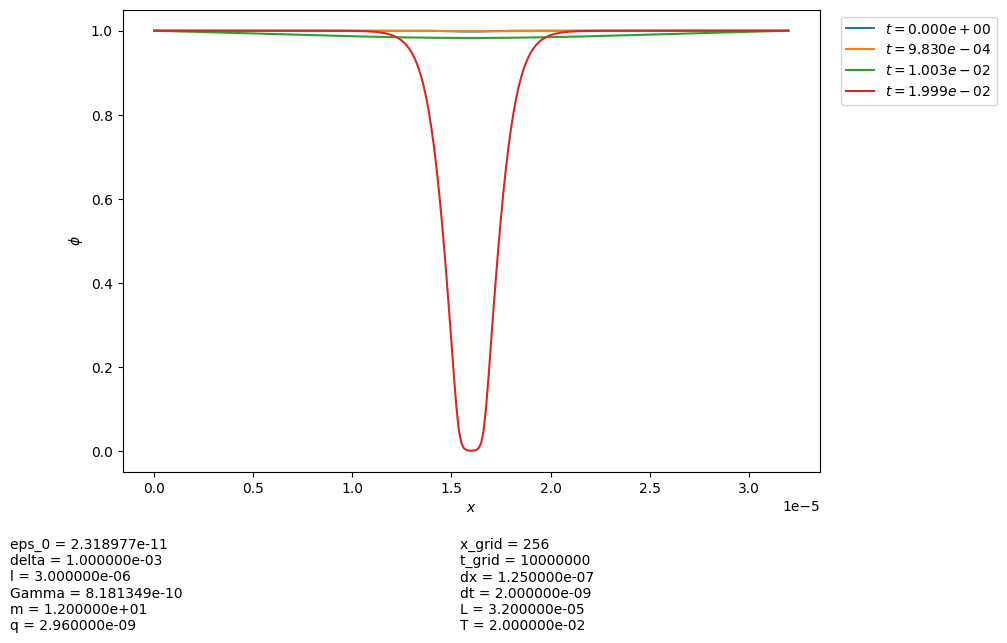

In [4]:
model_m3 = model_from_file(data_dir + 'model_m3.csv')
model_plot(model_m3, [0, 1e-3, 1e-2, 2e-2], figsize=(9, 6))

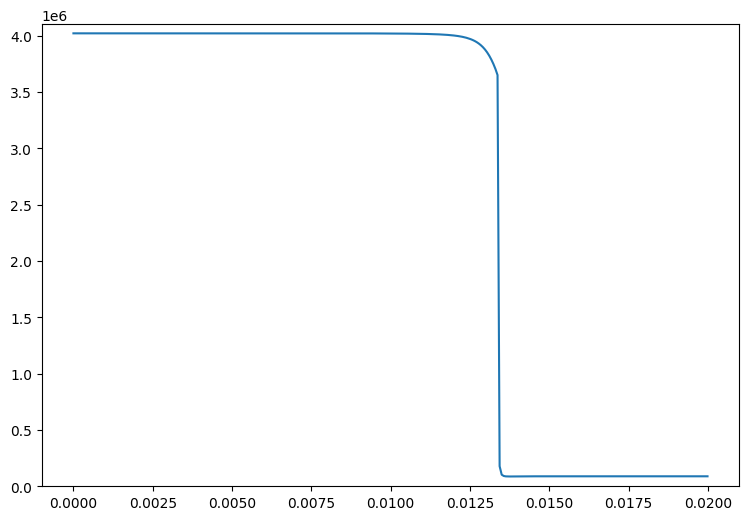

In [5]:
plt.figure(figsize=(9, 6))
plt.ylim([0, model_m3.E[0] * 1.02])
plt.plot(model_m3.ts, model_m3.E)
plt.show()

In [6]:
model_m3.phi[-1].min()

np.float64(0.000518641316)

In [7]:
model_m3.E[0] / model_m3.E[-1]

np.float64(45.39895336228655)

$\delta$ уменьшим в $100$ раз, $q$ увеличим в $10$.

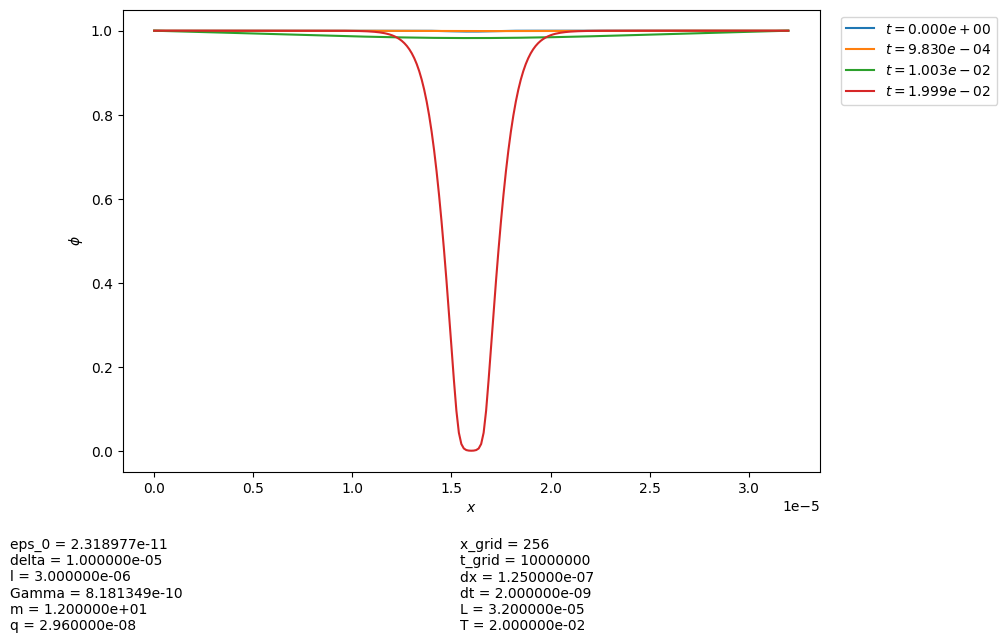

In [8]:
model_m5 = model_from_file(data_dir + 'model_m5.csv')
model_plot(model_m5, [0, 1e-3, 1e-2, 2e-2], figsize=(9, 6))

In [9]:
model_m5.E[0] / model_m5.E[-1]

np.float64(4539.93665012865)

Профиль канала не изменился! Падение напряжения увеличилось $\sim \delta$, в $100$ раз; напряжение развития пробоя увеличилось $\sim \sqrt{\delta}$, а естественное напряжение уменьшилось $\sim 1 / \sqrt{\delta}$.

Возможна проблема, что нужно подбирать константу при $\delta^2$ во второй производной, чтобы образовывающийся канал был ширины $\approx l$.

Экспериментальная разработка -- неограниченный рост $\epsilon$:
$$g(\phi) = 1 - \cfrac{1}{\phi^2} \left[ (1.0 - 1000 \delta^2) (1 - \phi)^p + 1000 \delta^2 (1 - \phi)^2 \right].$$

Важно, чтобы выполнялось $\cfrac{g'}{(1 - g)^2} \to 0$ при $\phi \to +0$.

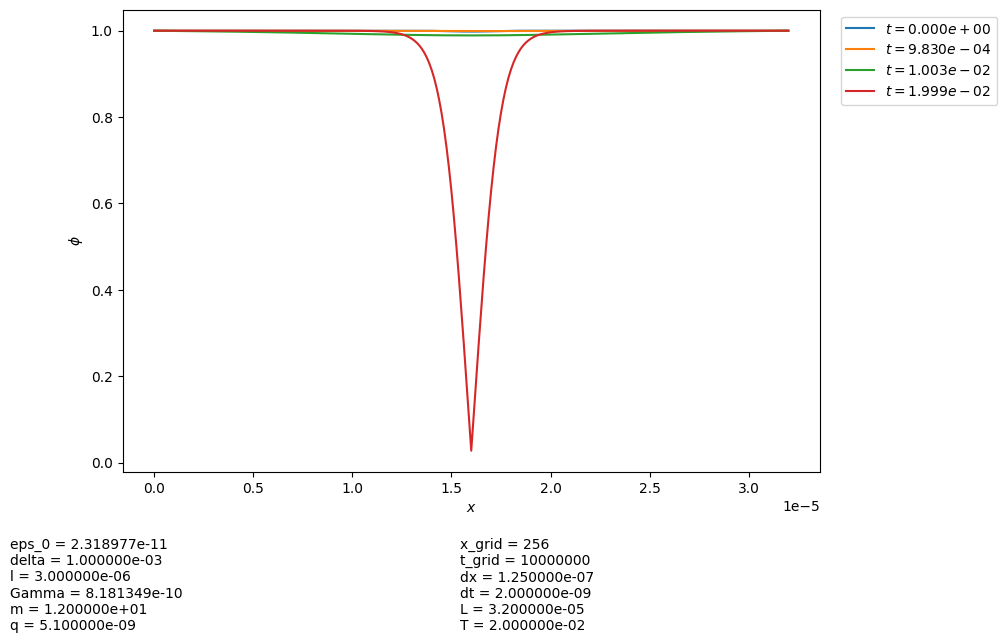

In [10]:
model_unbounded_m3 = model_from_file(data_dir + 'model_unbounded_m3.csv')
model_plot(model_unbounded_m3, [0, 1e-3, 1e-2, 2e-2], figsize=(9, 6))

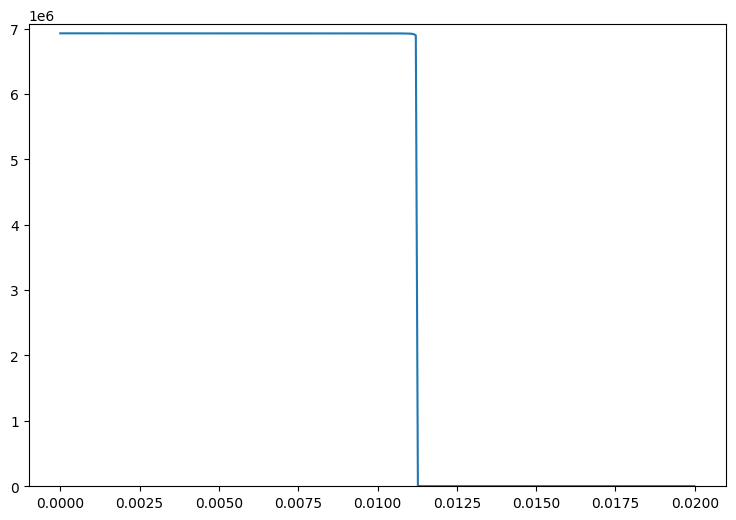

In [11]:
plt.figure(figsize=(9, 6))
plt.ylim([0, model_unbounded_m3.E[0] * 1.02])
plt.plot(model_unbounded_m3.ts, model_unbounded_m3.E)
plt.show()

In [12]:
model_unbounded_m3.phi[-1].min()

np.float64(0.0276129809)

In [13]:
model_unbounded_m3.E[0] / model_unbounded_m3.E[-1]

np.float64(2995.4644994690743)

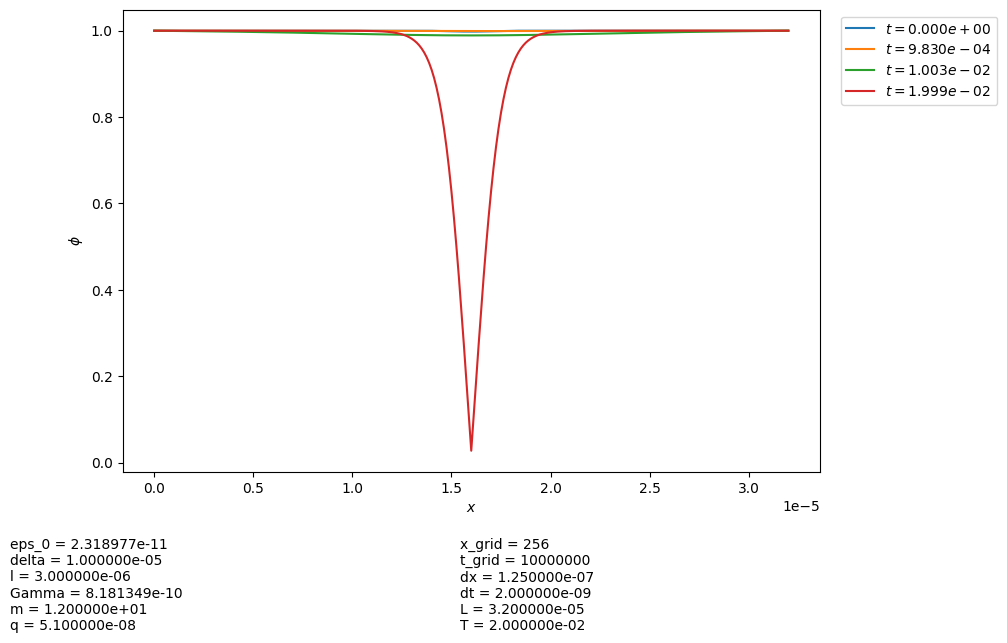

In [14]:
model_unbounded_m5 = model_from_file(data_dir + 'model_unbounded_m5.csv')
model_plot(model_unbounded_m5, [0, 1e-3, 1e-2, 2e-2], figsize=(9, 6))

In [15]:
model_unbounded_m5.phi[-1].min()

np.float64(0.0275806381)

In [16]:
model_unb_256 = model_from_file(data_dir + 'model_unbounded_256.csv')
model_unb_1024 = model_from_file(data_dir + 'model_unbounded_1024.csv')
model_unb_4096 = model_from_file(data_dir + 'model_unbounded_4096.csv')

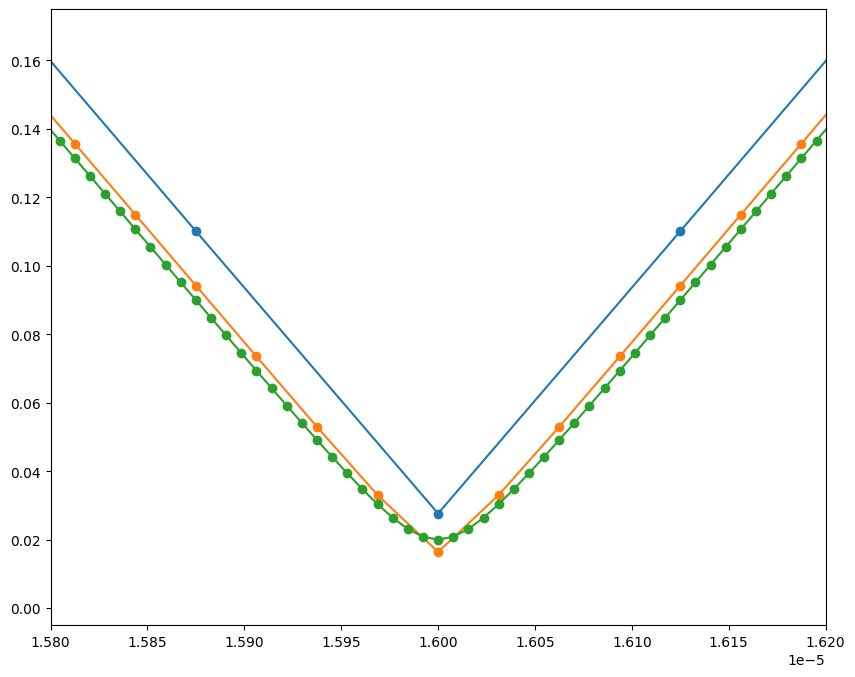

In [17]:
plt.figure(figsize=(10, 8))
plt.xlim([1.58e-5, 1.62e-5])
plt.ylim([-0.005, 0.175])
plt.plot(model_unb_256.xs, model_unb_256.phi[-1], '-o')
plt.plot(model_unb_1024.xs, model_unb_1024.phi[-1], '-o')
plt.plot(model_unb_4096.xs, model_unb_4096.phi[-1], '-o')
plt.show()

Судя по расчетам, на "кончике" профиля нет особенности! Но разрешить функцию на практике представляется невозможным.